In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb 

In [3]:
import os
os.getcwd()

'/Users/zakariaabdullahi/Documents/crypto-dashboard-DE25-UX25/eda'

In [4]:
df = pd.read_csv("../data/interim/master_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

- EDA 1 
 - Volitilaty: Mesauring the how the prise sways daily.
High Volitilaty = High Risk

In [ ]:
# EDA 1
# Standard Deviation of daily returns as a measure of thee volatility
vol = (
    df.groupby("coin_id")["daily_return_pct"]
    .std()
    .reset_index()
    .sort_values("daily_return_pct", ascending=False)
)
vol



,coin_id,daily_return_pct
1,dogwifcoin,6.726459
2,floki,5.820928
3,official-trump,5.326817
0,bitcoin,2.308453


### Insight

As we can see the Meme coins rise faster in the short term, but then they struggle to hold that price.
But on the other hand Bitcoin shows better development in the long term.

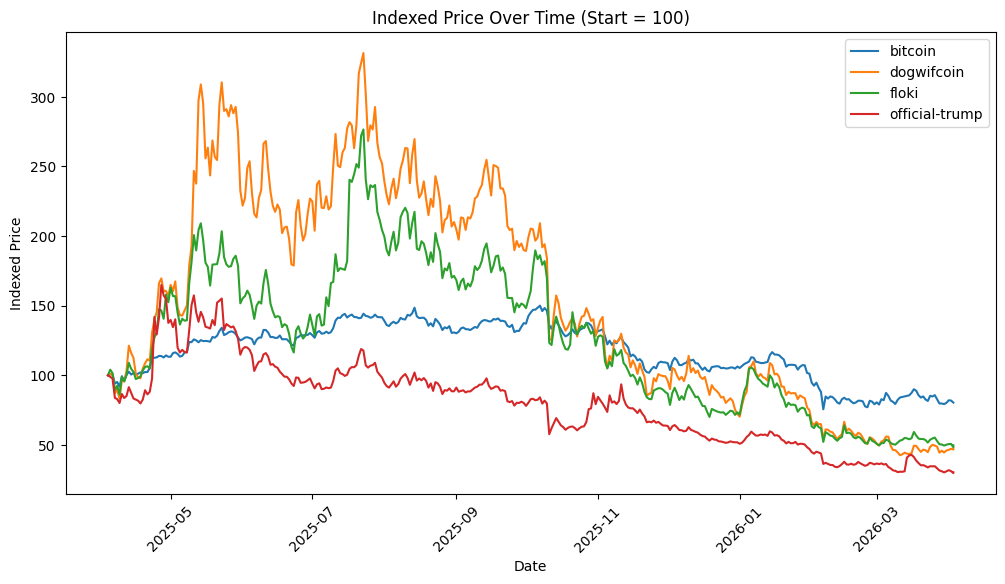

In [ ]:
# EDA 2 — Indexed Price 

df = df.sort_values(["coin_id", "date"])

df["price_index"] = df.groupby("coin_id")["price"].transform(
    lambda s: (s / s.iloc[0]) * 100
)

plt.figure(figsize=(12,6))

for coin in df["coin_id"].unique():
    coin_df = df[df["coin_id"] == coin]
    plt.plot(coin_df["date"], coin_df["price_index"], label=coin)

plt.title("Indexed Price Over Time (Start = 100)")
plt.xlabel("Date")
plt.ylabel("Indexed Price")
plt.legend()
plt.xticks(rotation=45)

plt.show()